# **Module 04 Lab02: Model Development - Laptop Pricing**

CISC7204 Assgn01 - Lab02 (Laptop Pricing) / Module 06 Final (House Pricing) | mc660725 Gao Si Han

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df = pd.read_csv("laptop_mod2.csv", header=0)
df = df.drop(['Unnamed: 0','Unnamed: 0.1'], axis=1, errors='ignore')
print("The first 5 rows")
df.head(5)

The first 5 rows


,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


### Task 1: Single Linear Regression - CPU_frequency vs Price

In [3]:
lm = LinearRegression()
X = df[['CPU_frequency']]
Y = df['Price']
lm.fit(X, Y)
print('Intercept:', lm.intercept_)
print('Coefficient:', lm.coef_)
print('R^2 (single):', lm.score(X, Y))

Intercept: 253.6611706858214
Coefficient: [1485.19362648]
R^2 (single): 0.1344436321024326


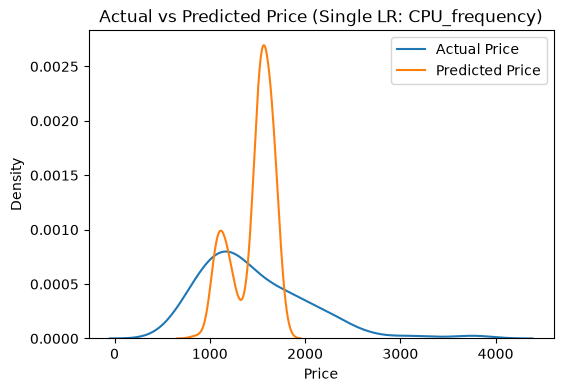

In [4]:
Yhat = lm.predict(X)
plt.figure(figsize=(6,4))
sns.distplot(Y, hist=False, label='Actual Price')
sns.distplot(Yhat, hist=False, label='Predicted Price')
plt.title('Actual vs Predicted Price (Single LR: CPU_frequency)')
plt.xlabel('Price')
plt.legend()
plt.show()

### Task 2: Multiple Linear Regression
Features: CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU, Category.

In [5]:
mlr_features = ['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']
Z = df[mlr_features]
mlr = LinearRegression()
mlr.fit(Z, Y)
print('R^2 (multiple):', mlr.score(Z, Y))
Yhat_mlr = mlr.predict(Z)

R^2 (multiple): 0.5082509055187376


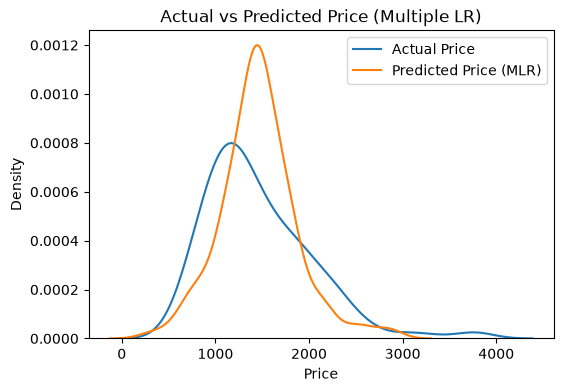

In [6]:
plt.figure(figsize=(6,4))
sns.distplot(Y, hist=False, label='Actual Price')
sns.distplot(Yhat_mlr, hist=False, label='Predicted Price (MLR)')
plt.title('Actual vs Predicted Price (Multiple LR)')
plt.xlabel('Price')
plt.legend()
plt.show()

### Task 3: Polynomial Regression on CPU_frequency (degrees 1, 3, 5)

In [7]:
def PlotPolly(model, x, y, name):
    x_new = np.linspace(x.min(), x.max(), 100)
    y_new = model(x_new)
    plt.plot(x, y, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {name}')
    plt.xlabel(name); plt.ylabel('Price of laptops')

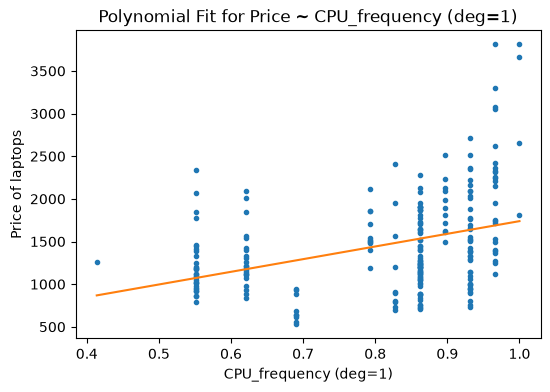

In [8]:
x = df['CPU_frequency']; y = df['Price']
plt.figure(figsize=(6,4))
model1 = np.polyfit(x, y, 1); PlotPolly(np.poly1d(model1), x, y, 'CPU_frequency (deg=1)')
plt.show()

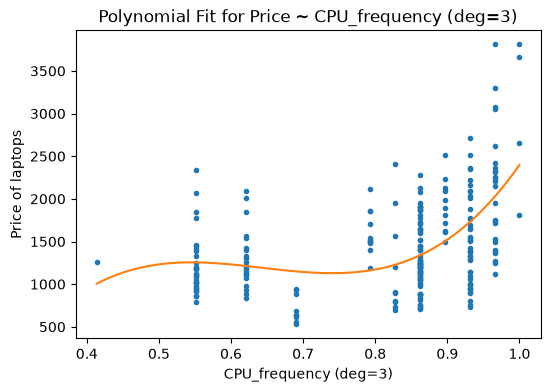

In [9]:
plt.figure(figsize=(6,4))
model3 = np.polyfit(x, y, 3); PlotPolly(np.poly1d(model3), x, y, 'CPU_frequency (deg=3)')
plt.show()

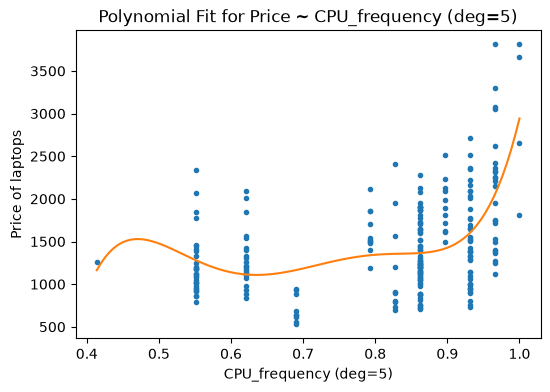

In [10]:
plt.figure(figsize=(6,4))
model5 = np.polyfit(x, y, 5); PlotPolly(np.poly1d(model5), x, y, 'CPU_frequency (deg=5)')
plt.show()

In [11]:
from sklearn.metrics import r2_score
print('R^2 deg=3:', r2_score(y, np.poly1d(model3)(x)))
print('R^2 deg=5:', r2_score(y, np.poly1d(model5)(x)))

R^2 deg=3: 0.26692640796531153
R^2 deg=5: 0.3030822706442994


### Task 4: Pipeline - StandardScaler -> PolynomialFeatures -> LinearRegression

In [12]:
Input = [('scale', StandardScaler()),
         ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
         ('model', LinearRegression())]
pipe = Pipeline(Input)
pipe.fit(Z, Y)
print('Pipeline R^2:', pipe.score(Z, Y))

Pipeline R^2: 0.6332094535859658


# Module 04 complete.